# Set environment

In [19]:
### Basic
import numpy  as np
import scipy  as sc
import pandas as pd
import glob, os, re
import pickle, sys
import math

### CUDA
from numba import cuda, vectorize

### plotting
import matplotlib.pyplot as plt
plt.style.use('seaborn-darkgrid')

In [2]:
%matplotlib inline

# Smoothing with CUDA

In [45]:
### define a point type
point_dtype = np.dtype({
    'names':   ['x', 'y'],
    'formats': [np.float32, np.float32]})

### calculate squared distance
@cuda.jit(device = True)
def dist2_kernel(point1, point2):
    return math.pow(point1["x"] - point2["x"], 2) + math.pow(point1["y"] - point2["y"], 2)

### convert squared distance into exponential
@cuda.jit(device = True)
def dist2weight_kernel(dist2, sig2 = 1):
    #if (kernel == "standard normal"):
    return math.exp(-1 * dist2 / sig2)

### wrap function of distance and weight function
### signature: point_dtype[:], point_dtype[:], float[:, :]
@cuda.jit
def get_weights(grids, points, weights, sig2 = 1):
    # set index of cuda
    idx_grid, idx_point = cuda.grid(2)
    if (idx_grid < weights.shape[0]) & (idx_point < weights.shape[1]):
        # intialization
        grid  = grids[idx_grid]
        point = points[idx_point]
        
        # calculate distance and then convert to weights
        dist2 = dist2_kernel(grid, point)
        weights[idx_grid, idx_point] = dist2weight_kernel(dist2, sig2)

####################################################
### helper function: convert coordinate into point
def set_points(dat_pts):
    """Convert data frame of coordinates to an array of points
    
    >>> tmp = np.arange(10).reshape(-1, 2)
    >>> set_points(tmp)
    ... array([(0., 1.), (2., 3.), (4., 5.), (6., 7.), (8., 9.)],
      dtype=[('x', '<f8'), ('y', '<f8')])
    >>> set_points(tmp)[0]['x'], set_points(tmp)[0]['y']
    ... (0.0, 1.0)
    """
    ### initialization
    num_pts = dat_pts.shape[0]
    points = np.empty((num_pts,), dtype = point_dtype)
    
    ### convert each row into a point
    for idx in range(num_pts):
        p = points[idx]
        p['x'], p['y'] = dat_pts[idx][0], dat_pts[idx][1]
    
    return points

####################################################
def get_coord_grid(coord, ngrid):
    """create grid from coordination of k samples"""
    ### Coordinate
    x = coord[:, 0]
    y = coord[:, 1]
        
    ### set coordinate of grids
    xc = np.linspace(min(x), max(x), ngrid)
    yc = np.linspace(min(y), max(y), ngrid)
    xc, yc = np.meshgrid(xc, yc)
        
    ### the return grids coordinate with shape (ngrid x ngrid, 2)
    grids = np.array([xc.ravel(), yc.ravel()]).T
    assert grids.shape == (ngrid**2, 2)
    return grids

####################################################
def ksmooth_cuda(matrix, coord, sig2, ngrid):
    # Sample data (vector for each feature)
    #matrix = dat.get_sample(idx_sample)
    
    # Coordinate from dimensional reduction
    #coord  = dat.get_coord(idx_sample)
    points = set_points(coord)
            
    # generate a grid of a frame
    #grids = dat.get_coord_grid(idx_sample, self.ngrid)
    grids = get_coord_grid(coord, ngrid)
    grids = set_points(grids)
            
    # cuda memory blocks
    threadsperblock = (16, 16)
    blockspergrid_x = math.ceil(grids.shape[0]  / threadsperblock[0])
    blockspergrid_y = math.ceil(points.shape[0] / threadsperblock[1])
    blockspergrid = (blockspergrid_x, blockspergrid_y)
            
    # calculate the weights for smoothing
    weights = np.empty(shape = (grids.shape[0], points.shape[0]), dtype = np.float32)
    #get_weights[blockspergrid, threadsperblock](grids, points, weights, self.sig2)
    get_weights[blockspergrid, threadsperblock](grids, points, weights, sig2)
    ################################
            
    # for each feature, generate each frame and store in an image
    img = []
    nr, nc = matrix.shape
    
    #for idx_feature in range(dat.get_num_variable()):
    for idx_feature in range(nc):
        # interpolation
        z = matrix[:, idx_feature]
        zc = np.matmul(weights, z)
        
        # store into a list "img"
        img.append(zc)
        
    # collect the image of each sample
    img = np.array(img)
    #lst_img.append(img.T)
    return img.T

# Smoothing without CUDA

In [63]:
def dist2_fun(point1, point2):
    return math.pow(point1["x"] - point2["x"], 2) + math.pow(point1["y"] - point2["y"], 2)

def dist2weight(dist2, sig2 = 1):
    return math.exp(-1 * dist2 / sig2)

def get_weights2(grids, points, weights, sig2 = 1):
    # set index of cuda
    #idx_grid, idx_point = cuda.grid(2)
    for idx_grid in range(weights.shape[0]):
        grid  = grids[idx_grid]
        
        for idx_point in range(weights.shape[1]):
            point = points[idx_point]
        
            # calculate distance and then convert to weights
            dist2 = dist2_fun(grid, point)
            weights[idx_grid, idx_point] = dist2weight(dist2, sig2)
        
####################################################
def ksmooth(matrix, coord, sig2, ngrid):
    ### generate a grid of a frame
    grids = get_coord_grid(coord, ngrid)
    
    ### set points
    grids  = set_points(grids)
    points = set_points(coord)
                    
    # calculate the weights for smoothing
    weights = np.empty(shape = (grids.shape[0], points.shape[0]), dtype = np.float32)
    get_weights2(grids, points, weights, sig2)
    ################################
            
    # for each feature, generate each frame and store in an image
    img = []
    nr, nc = matrix.shape
    
    #for idx_feature in range(dat.get_num_variable()):
    for idx_feature in range(nc):
        # interpolation
        z = matrix[:, idx_feature]
        zc = np.matmul(weights, z)
        
        # store into a list "img"
        img.append(zc)
        
    # collect the image of each sample
    img = np.array(img)
    #lst_img.append(img.T)
    return img.T

# Generate points

In [6]:
def generate_sample(mean, cov, num_events):
    """......"""
    assert mean.shape[0] == cov.shape[0]
    assert mean.shape[0] == num_events.shape[0]
    
    num_clusters = mean.shape[0]
    dat = [np.random.multivariate_normal(mean[idx], cov[idx], num_events[idx]) for idx in range(num_clusters)]
    dat = np.concatenate(dat)
    return dat

In [46]:
### Generate data
mu1 = np.array([[0, 0],[5, 5]])        ### Mean
sd1 = np.array([np.eye(2), np.eye(2)]) ### SD
nc1 = np.array([100, 900])               ### number of cells
ns1 = 10                               ### number of samples
y   = generate_sample(mu1, sd1, nc1)

In [49]:
N = 1000
mat = np.array([1] * N).reshape(N, -1)
mat.shape

(1000, 1)

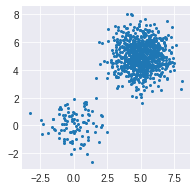

In [52]:
fig, axes = plt.subplots(ncols=1, nrows=1, figsize = (3*1, 3*1))
axes.scatter(y[:,0], y[:, 1], s = 4)
pass

In [64]:
%time img1 = ksmooth(mat, y, 2, 128)
%time img2 = ksmooth_cuda(mat, y, 2, 128)

print(img1.shape)
print(img2.shape)
print(np.allclose(img1, img2))

CPU times: user 43.1 s, sys: 203 ms, total: 43.3 s
Wall time: 43.1 s
CPU times: user 611 ms, sys: 1.61 s, total: 2.22 s
Wall time: 176 ms
(16384, 1)
(16384, 1)
True


In [67]:
grids = get_coord_grid(y, 128)
xc, yc = grids[:, 0], grids[:, 1]

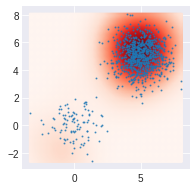

In [75]:
fig, axes = plt.subplots(ncols=1, nrows=1, figsize = (3*1, 3*1))
axes.scatter(xc, yc, c = img[:,0], s = 4, cmap = "Reds")
axes.scatter(y[:,0], y[:, 1],      s = 1, cmap = "Blues", alpha = 0.7)
pass